# CICIoT2023 — end-to-end use-case walkthrough

Runs the **real** CICIoT2023 pipeline interactively: load → data-quality audit →
leakage-safe preprocessing → supervised baselines → interpretation. It uses the
consolidated `src/ciciot2023.py` (not toy code); model settings are lightened for
a snappy in-notebook run, so numbers are close to `results/ciciot2023_baselines.md`.

**Dataset:** CIC IoT 2023 (Neto et al.) — IoT-topology traffic, 33 attacks in 7
categories + benign, 105 devices. We use a pre-split downsampled **parquet dev
sample**. Three label levels ship in the data: binary, 8-category, 34-fine.

In [1]:
# --- setup ---------------------------------------------------------------
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ.setdefault("OMP_NUM_THREADS", "1")
import sys, warnings
from pathlib import Path
_here = Path.cwd(); ROOT = _here if (_here/"src").is_dir() else _here.parent
sys.path.insert(0, str(ROOT/"src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import ciciot2023 as C, evaluate as E
get_ipython().run_line_magic("matplotlib", "inline")
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid")
SEED = 42; SUB = 100_000
print("ready — CICIoT2023 module loaded")

ready — CICIoT2023 module loaded


## Step 1 — Load & the three label levels

In [2]:
train, test = C.load_parquet("train"), C.load_parquet("test")
print("train:", train.shape, " test:", test.shape)
print("\nLevel 1 (binary):", dict(train["binary_label"].value_counts()))
print("\nLevel 2 (8-category):")
print(train["attack_category"].value_counts().reindex(C.CATEGORY_ORDER).to_string())
print("\nLevel 3 (fine):", train["label"].nunique(), "attack types")

train: (1073851, 42)  test: (268463, 42)

Level 1 (binary): {1: np.int64(913861), 0: np.int64(159990)}

Level 2 (8-category):
attack_category
Benign         159990
DDoS           361842
DoS            159925
Recon          161877
Web-based       19820
Brute Force     10457
Spoofing        80043
Mirai          119897

Level 3 (fine): 32 attack types


Note the imbalance even in this downsampled dev set: **DDoS dominates**, while
**Web-based** and **Brute Force** are tiny — the classes to watch.

## Step 2 — Data-quality & leakage audit

In [3]:
print("\n".join(C.data_quality_audit(train, "train")))

### train  (1,073,851 rows x 39 features)

- missing cells: **0**
- infinite cells: **0**
- duplicated rows: **84,370** (7.86%)
- constant features: **0** 
- near-constant (>99.9% one value): **2** ['Telnet', 'SMTP']
- binary/category consistency: **OK**



All features numeric, no missing/inf, no socket-identifier columns (so the
CICFlowMeter host/time **leakage risk is already avoided**). A chunk of exact
duplicate rows exists — worth noting, but expected in flow captures.

## Step 3 — Preprocess (scale-only, leakage-safe)

Every feature is numeric, so preprocessing is **StandardScaler only** — no
one-hot (unlike NSL-KDD). The scaler is fit on **train only**.

In [4]:
prep_b = C.prepare(train, test, level="binary")
# prove no leakage: scaler means == train feature means
tm = train[prep_b.feature_names].mean().to_numpy()
print("features:", prep_b.n_features, " | no-leakage (scaler==train means):",
      np.allclose(prep_b.scaler.mean_, tm, atol=1e-6))
print("X_train:", prep_b.X_train.shape, " classes:", prep_b.classes)

features: 39  | no-leakage (scaler==train means): True
X_train: (1073851, 39)  classes: ['Benign', 'Attack']


In [5]:
def show_confusion(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(1, 2, figsize=(5+1.1*len(classes), 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax[0])
    ax[0].set(title="counts", xlabel="predicted", ylabel="true")
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", cbar=False, vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax[1])
    ax[1].set(title="recall", xlabel="predicted", ylabel="true")
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()

def zoo():
    return {
        "Dummy": DummyClassifier(strategy="stratified", random_state=SEED),
        "LogReg (bal)": LogisticRegression(class_weight="balanced", max_iter=800, n_jobs=-1),
        "RandomForest (bal)": RandomForestClassifier(n_estimators=150,
            class_weight="balanced", random_state=SEED, n_jobs=-1),
        "HistGB (bal)": HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
        "LightGBM (bal)": LGBMClassifier(n_estimators=200, class_weight="balanced",
            random_state=SEED, n_jobs=1, num_threads=1, verbose=-1),
    }

def sub(X, y, n):
    if len(y) <= n: return X, y
    Xs, _, ys, _ = train_test_split(X, y, train_size=n, stratify=y, random_state=SEED)
    return Xs, ys
print("helpers defined")

helpers defined


## Step 4 — Baselines: binary (benign vs attack)

,accuracy,bal_acc,macro_F1,ROC_AUC,attack_recall
model,,,,,
Dummy,0.7451,0.4983,0.4983,0.4983,0.8499
LogReg (bal),0.8187,0.8867,0.7495,0.9327,0.7898
RandomForest (bal),0.9146,0.9040,0.8523,0.9676,0.9191
HistGB (bal),0.8913,0.9251,0.8298,0.9682,0.8770
LightGBM (bal),0.8981,0.9258,0.8376,0.9697,0.8864


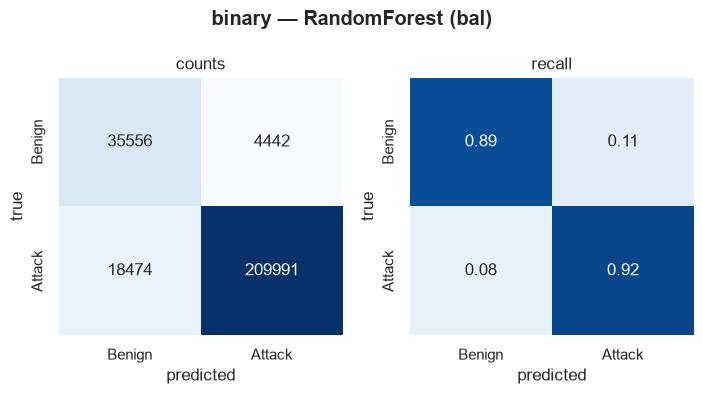

In [6]:
Xtr, ytr = sub(prep_b.X_train, prep_b.y_train, SUB)
rows, fitted = [], {}
for name, m in zoo().items():
    m.fit(Xtr, ytr); fitted[name] = m
    yp = m.predict(prep_b.X_test)
    ys = m.predict_proba(prep_b.X_test)[:,1] if hasattr(m,"predict_proba") else None
    d = E.compute_metrics(prep_b.y_test, yp, prep_b.classes, y_score=ys)
    rows.append({"model": name, "accuracy": round(d["accuracy"],4),
                 "bal_acc": round(balanced_accuracy_score(prep_b.y_test, yp),4),
                 "macro_F1": round(d["macro_f1"],4),
                 "ROC_AUC": round(d.get("roc_auc",float("nan")),4),
                 "attack_recall": round(d["per_class"]["Attack"]["recall"],4)})
display(pd.DataFrame(rows).set_index("model"))
best = max(rows, key=lambda r: r["macro_F1"])["model"]
show_confusion(prep_b.y_test, fitted[best].predict(prep_b.X_test), prep_b.classes,
               f"binary — {best}")

## Step 5 — Baselines: 8-category (and the rare-class story)

,accuracy,bal_acc,macro_F1,Web_recall,BruteForce_recall
model,,,,,
Dummy,0.1993,0.1250,0.1250,0.020,0.008
LogReg (bal),0.6819,0.6277,0.5716,0.465,0.387
RandomForest (bal),0.8276,0.7142,0.7283,0.312,0.338
HistGB (bal),0.8069,0.7542,0.6996,0.591,0.557
LightGBM (bal),0.8206,0.7524,0.7190,0.558,0.482


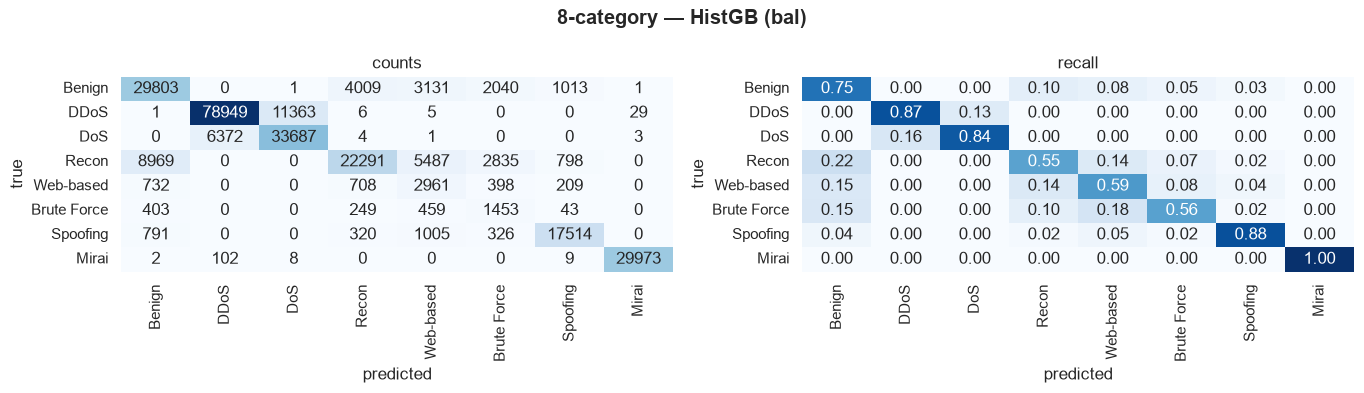

In [7]:
prep_c = C.prepare(train, test, level="category")
Xtr, ytr = sub(prep_c.X_train, prep_c.y_train, SUB)
rows, fitted = [], {}
for name, m in zoo().items():
    m.fit(Xtr, ytr); fitted[name] = m
    yp = m.predict(prep_c.X_test)
    d = E.compute_metrics(prep_c.y_test, yp, prep_c.classes)
    pc = d["per_class"]
    rows.append({"model": name, "accuracy": round(d["accuracy"],4),
                 "bal_acc": round(balanced_accuracy_score(prep_c.y_test, yp),4),
                 "macro_F1": round(d["macro_f1"],4),
                 "Web_recall": round(pc["Web-based"]["recall"],3),
                 "BruteForce_recall": round(pc["Brute Force"]["recall"],3)})
display(pd.DataFrame(rows).set_index("model"))
show_confusion(prep_c.y_test, fitted["HistGB (bal)"].predict(prep_c.X_test),
               prep_c.classes, "8-category — HistGB (bal)")

## Interpretation & takeaways

- **Your metric picks the winner.** RandomForest usually tops **macro-F1**, but
  **HistGB** leads **balanced-accuracy** and **rare-class recall** (Web-based,
  Brute Force). The macro-F1 leader can be the *worse* model for catching the rare
  attacks — always read per-class recall, not just the headline.
- **Preprocessing is scale-only** here (all-numeric features) — simpler than
  NSL-KDD's one-hot, and leakage-safe by fitting on train only.
- **Caveat:** this is a *random* in-distribution split, so scores are optimistic
  vs a device- or time-based split (a later stage).

**Next stages (branch by branch):** MLP + activation ablations, the imbalance
arsenal (SMOTE/focal/thresholds + FP-per-10k-benign), and benign-only anomaly
detection with held-out attack categories (zero-day proxy).